In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from smart_grid_lab.core import Time

# Load data

In [3]:
load_df = pd.read_csv("data/load_kW.csv")

In [4]:
load_df.index = pd.to_datetime(load_df.utc_timestamp, utc=True)
load_df = load_df.drop("utc_timestamp", axis='columns')

In [5]:
time = Time(
    start=pd.Timestamp(year=2016, month=3, day=15, hour=12, tz="utc"),
    end=pd.Timestamp(year=2016, month=3, day=20, hour=12, tz="utc"),
    step=pd.Timedelta(15, "min"),
)

<Axes: xlabel='utc_timestamp'>

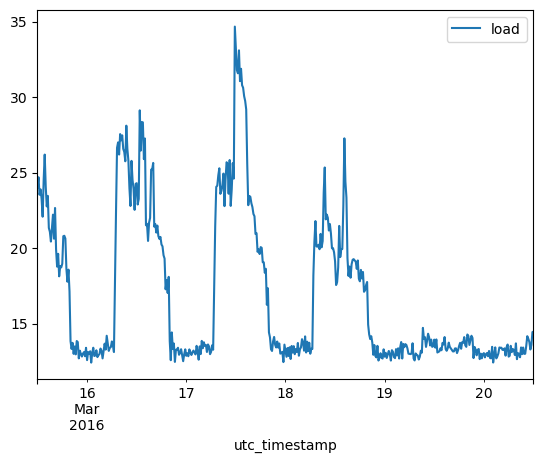

In [6]:
load_df[time.start : time.end].plot()

In [16]:
TARGET = "load"

# Add features

In [10]:
def append_time_features(df: pd.DataFrame, target: str):
    df = df.copy()

    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["dayofyear"] = df.index.dayofyear
    df["weekofyear"] = df.index.isocalendar().week.astype(int)

    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)

    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)

    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    df["load_lag_1h"] = df[target].shift(4)

    df["load_lag_6h"] = df[target].shift(24)

    df["load_lag_24h"] = df[target].shift(96)

    df["load_lag_48h"] = df[target].shift(192)

    df["load_lag_7d"] = df[target].shift(96 * 7)

    df["load_roll_mean_24h"] = df[target].shift(1).rolling(96).mean()

    df["load_roll_std_24h"] = df[target].shift(1).rolling(96).std()

    df = df.dropna()

    return df

In [11]:
load_df = append_time_features(load_df, TARGET)

In [12]:
load_df.head()

,load,hour,dayofweek,month,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_lag_1h,load_lag_6h,load_lag_24h,load_lag_48h,load_lag_7d,load_roll_mean_24h,load_roll_std_24h
utc_timestamp,,,,,,,,,,,,,,,,,,
2014-12-18 18:00:00+00:00,0.042,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.021,0.018,0.019,0.018,0.034,0.081948,0.107700
2014-12-18 18:15:00+00:00,0.085,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.016,0.019,0.341,0.300,0.018,0.082187,0.107584
2014-12-18 18:30:00+00:00,0.455,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.019,0.041,0.168,0.251,0.018,0.079521,0.104222
2014-12-18 18:45:00+00:00,0.368,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.020,0.033,0.350,0.326,0.018,0.082510,0.110701
2014-12-18 19:00:00+00:00,0.316,19,3,12,352,51,0,-0.965926,2.588190e-01,0.433884,-0.900969,0.042,0.022,0.347,0.246,0.021,0.082698,0.111173


# Devide Train Test Validate

In [13]:
train_end = pd.Timestamp(year=2018, month=10, day=1, tz="utc")
val_end = pd.Timestamp(year=2018, month=11, day=1, tz="utc")

In [14]:
train_df = load_df.loc[:train_end]

val_df = load_df.loc[train_end:val_end]

test_df = load_df.loc[val_end:]

In [15]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(132697, 18)
(2977, 18)
(17465, 18)


In [18]:
FEATURES = [c for c in load_df.columns if c != TARGET]

FEATURES

['hour',
 'dayofweek',
 'month',
 'dayofyear',
 'weekofyear',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'load_lag_1h',
 'load_lag_6h',
 'load_lag_24h',
 'load_lag_48h',
 'load_lag_7d',
 'load_roll_mean_24h',
 'load_roll_std_24h']

In [19]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# Prepare for OpenSTEF

In [21]:
openstef_df = load_df.reset_index()

openstef_df.rename(
    columns={
        load_df.index.name: "datetime",
        TARGET: "load",
    },
    inplace=True,
)

openstef_df.head()

,datetime,load,hour,dayofweek,month,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_lag_1h,load_lag_6h,load_lag_24h,load_lag_48h,load_lag_7d,load_roll_mean_24h,load_roll_std_24h
0,2014-12-18 18:00:00+00:00,0.042,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.021,0.018,0.019,0.018,0.034,0.081948,0.107700
1,2014-12-18 18:15:00+00:00,0.085,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.016,0.019,0.341,0.300,0.018,0.082187,0.107584
2,2014-12-18 18:30:00+00:00,0.455,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.019,0.041,0.168,0.251,0.018,0.079521,0.104222
3,2014-12-18 18:45:00+00:00,0.368,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.020,0.033,0.350,0.326,0.018,0.082510,0.110701
4,2014-12-18 19:00:00+00:00,0.316,19,3,12,352,51,0,-0.965926,2.588190e-01,0.433884,-0.900969,0.042,0.022,0.347,0.246,0.021,0.082698,0.111173


In [36]:
sample = load_df.iloc[-96 * 7 :]

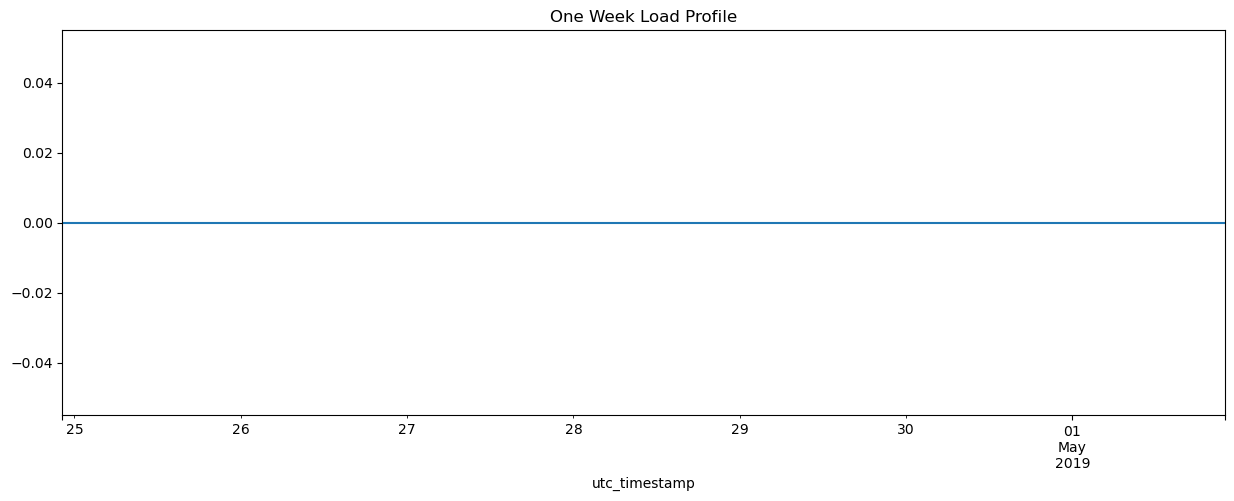

In [37]:
sample["load"].plot(figsize=(15, 5))

plt.title("One Week Load Profile")

plt.show()

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

In [39]:
naive_pred = y_test.shift(96)

mask = naive_pred.notna()

mae = mean_absolute_error(
    y_test[mask],
    naive_pred[mask],
)

rmse = np.sqrt(
    mean_squared_error(
        y_test[mask],
        naive_pred[mask],
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 0.0
RMSE: 0.0


# Train the model

In [40]:
FORECAST_HORIZON = 12

# Inspect openstef

In [1]:
from typing import Any, cast

In [2]:
from datetime import datetime, timedelta

from openstef_core.testing import load_liander_dataset

dataset = load_liander_dataset()

train_start = datetime.fromisoformat("2024-03-01T00:00:00Z")
train_end = train_start + timedelta(days=45)
forecast_end = train_end + timedelta(days=7)

train_dataset = dataset.filter_by_range(start=train_start, end=train_end)

# Include 14 days of history before forecast start for lag feature computation
predict_dataset = dataset.filter_by_range(
    start=train_end - timedelta(days=14),
    end=forecast_end,
)

print(
    f"Training:  {train_dataset.data.shape[0]:,} rows, "
    f"{train_dataset.data.index.min():%Y-%m-%d} to {train_dataset.data.index.max():%Y-%m-%d}"
)
print(
    f"Predict:   {predict_dataset.data.shape[0]:,} rows, "
    f"{predict_dataset.data.index.min():%Y-%m-%d} to {predict_dataset.data.index.max():%Y-%m-%d}"
)

Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.
Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.
Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.
Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.


Training:  4,320 rows, 2024-03-01 to 2024-04-14
Predict:   2,016 rows, 2024-04-01 to 2024-04-21


AttributeError: 'Axes' object has no attribute 'update_layout'

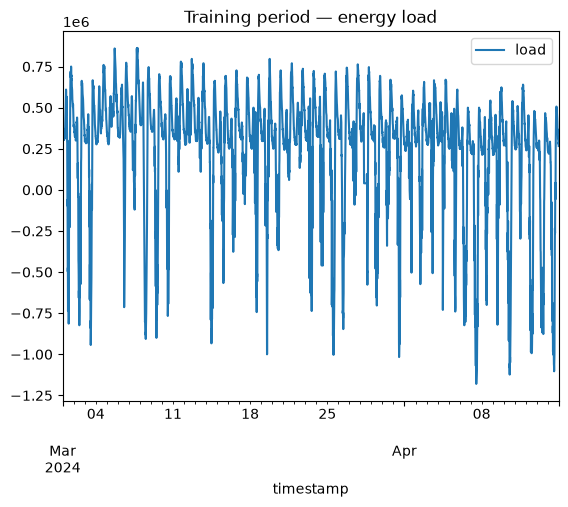

In [3]:
# Quick look at the target variable
fig = cast(Any, train_dataset.data[["load"]].plot(title="Training period — energy load"))
fig.update_layout(yaxis_title="Load (MW)", xaxis_title="Time")
fig.show()

In [3]:
from openstef.data_classes.prediction_job import PredictionJobDataClass

pj = PredictionJobDataClass(
    id=287,
    model="xgb",
    resolution_minutes=15,
    forecast_type="demand",
    quantiles=[10, 30, 50, 70, 90],
)

ValidationError: 1 validation error for PredictionJobDataClass
name
  Field required [type=missing, input_value={'id': 287, 'model': 'xgb...': [10, 30, 50, 70, 90]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

In [41]:
from openstef.pipeline.train_model import PredictionJobDataClass

/home/eduard/anaconda3/envs/energy-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:
print(PredictionJobDataClass.model_fields.keys())

dict_keys(['id', 'model', 'model_kwargs', 'forecast_type', 'horizon_minutes', 'resolution_minutes', 'lat', 'lon', 'name', 'electricity_bidding_zone', 'train_components', 'description', 'quantiles', 'train_split_func', 'backtest_split_func', 'train_horizons_minutes', 'default_modelspecs', 'save_train_forecasts', 'completeness_threshold', 'minimal_table_length', 'flatliner_threshold_minutes', 'detect_non_zero_flatliner', 'predict_non_zero_flatliner', 'data_balancing_ratio', 'rolling_aggregate_features', 'depends_on', 'sid', 'turbine_type', 'n_turbines', 'hub_height', 'pipelines_to_run', 'alternative_forecast_model_pid', 'data_prep_class', 'model_run_id', 'fallback_strategy'])


In [43]:
from openstef.pipeline.train_model import (
    PredictionJobDataClass,
)

In [44]:
pj = PredictionJobDataClass(
    id="microgrid_load",
    name="Microgrid Load Forecast",
    model="xgb",
    forecast_type="demand",
)

In [45]:
train_df.head()

,load,hour,dayofweek,month,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_lag_1h,load_lag_6h,load_lag_24h,load_lag_48h,load_lag_7d,load_roll_mean_24h,load_roll_std_24h
utc_timestamp,,,,,,,,,,,,,,,,,,
2014-12-18 18:00:00+00:00,0.042,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.021,0.018,0.019,0.018,0.034,0.081948,0.107700
2014-12-18 18:15:00+00:00,0.085,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.016,0.019,0.341,0.300,0.018,0.082187,0.107584
2014-12-18 18:30:00+00:00,0.455,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.019,0.041,0.168,0.251,0.018,0.079521,0.104222
2014-12-18 18:45:00+00:00,0.368,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.020,0.033,0.350,0.326,0.018,0.082510,0.110701
2014-12-18 19:00:00+00:00,0.316,19,3,12,352,51,0,-0.965926,2.588190e-01,0.433884,-0.900969,0.042,0.022,0.347,0.246,0.021,0.082698,0.111173


In [46]:
train_df.columns

Index(['load', 'hour', 'dayofweek', 'month', 'dayofyear', 'weekofyear',
       'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'load_lag_1h', 'load_lag_6h', 'load_lag_24h', 'load_lag_48h',
       'load_lag_7d', 'load_roll_mean_24h', 'load_roll_std_24h'],
      dtype='object')

In [47]:
cols = train_df.columns.tolist()

cols.remove("load")

train_df = train_df[["load"] + cols]

In [48]:
train_df.head()

,load,hour,dayofweek,month,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_lag_1h,load_lag_6h,load_lag_24h,load_lag_48h,load_lag_7d,load_roll_mean_24h,load_roll_std_24h
utc_timestamp,,,,,,,,,,,,,,,,,,
2014-12-18 18:00:00+00:00,0.042,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.021,0.018,0.019,0.018,0.034,0.081948,0.107700
2014-12-18 18:15:00+00:00,0.085,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.016,0.019,0.341,0.300,0.018,0.082187,0.107584
2014-12-18 18:30:00+00:00,0.455,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.019,0.041,0.168,0.251,0.018,0.079521,0.104222
2014-12-18 18:45:00+00:00,0.368,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.020,0.033,0.350,0.326,0.018,0.082510,0.110701
2014-12-18 19:00:00+00:00,0.316,19,3,12,352,51,0,-0.965926,2.588190e-01,0.433884,-0.900969,0.042,0.022,0.347,0.246,0.021,0.082698,0.111173


In [ ]:
import inspect

In [ ]:
from openstef.pipeline.train_model import (
    train_model_pipeline_core,
)

In [ ]:
print(inspect.getsource(train_model_pipeline_core)[:8000])

In [ ]:
from openstef.model.regressors import xgb

In [ ]:
dir(xgb)

In [ ]:
from openstef.model.regressors import lgbm

In [ ]:
dir(lgbm)

In [ ]:
from openstef.pipeline.train_model import (
    PredictionJobDataClass,
)

In [ ]:
pj = PredictionJobDataClass(
    id="microgrid_load",
    name="Microgrid Load Forecast",
    model="xgb",
    forecast_type="demand",
)

# Test

# Plot results

# Validate

# Plot result

# Finalize the Inference -> into infrastructure